# Price Exploration -- DK1/DK2

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from da_forecast.sources.cache import ParquetCache
from da_forecast.config import RAW_DIR

cache = ParquetCache(RAW_DIR)

dk1 = cache.load("energinet", "DK_1", "day_ahead_prices")[["price_eur_mwh"]].copy()
dk2 = cache.load("energinet", "DK_2", "day_ahead_prices")[["price_eur_mwh"]].copy()

# Convert to CET for market-aligned analysis
dk1.index = dk1.index.tz_convert("Europe/Copenhagen")
dk2.index = dk2.index.tz_convert("Europe/Copenhagen")

dk1["hour"] = dk1.index.hour
dk1["weekday"] = dk1.index.weekday
dk1["month"] = dk1.index.month
dk1["date"] = dk1.index.date

dk2["hour"] = dk2.index.hour
dk2["weekday"] = dk2.index.weekday
dk2["month"] = dk2.index.month

print(f"DK1: {dk1.index.min()} to {dk1.index.max()}, {len(dk1)} hours")
print(f"DK2: {dk2.index.min()} to {dk2.index.max()}, {len(dk2)} hours")

DK1: 2024-10-01 02:00:00+02:00 to 2025-09-30 23:00:00+02:00, 8758 hours
DK2: 2024-10-01 02:00:00+02:00 to 2025-09-30 23:00:00+02:00, 8758 hours


### Hourly Profile
Classic double-peak pattern. Morning ramp (06-09) and evening peak (17-20) define the daily spread opportunity.

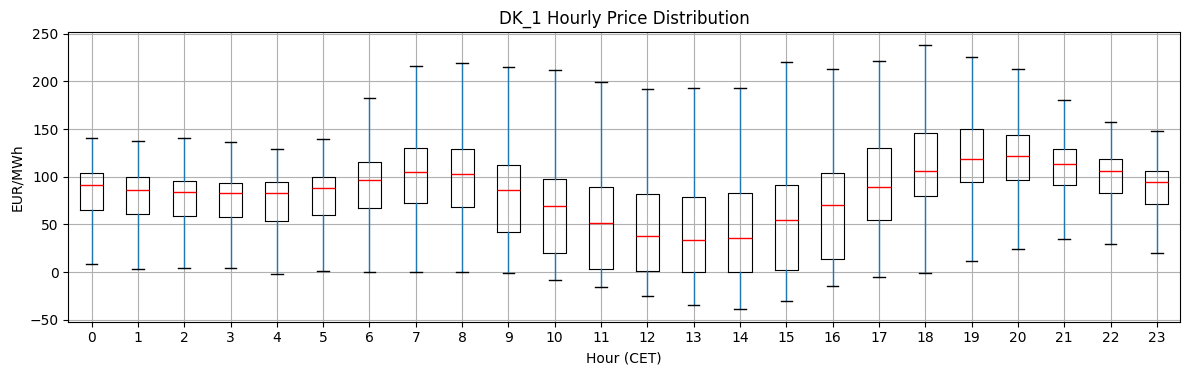

In [2]:
fig, ax = plt.subplots(figsize=(12, 4))
dk1.boxplot(column="price_eur_mwh", by="hour", ax=ax, showfliers=False,
            boxprops=dict(linewidth=0.8), medianprops=dict(color="red", linewidth=1))
ax.set_title("DK_1 Hourly Price Distribution")
ax.set_xlabel("Hour (CET)")
ax.set_ylabel("EUR/MWh")
plt.suptitle("")
fig.tight_layout()
plt.show()

### Weekly Pattern
Weekend demand drop of ~15-25% relative to weekday average. Saturday/Sunday prices consistently lower -- important calendar feature.

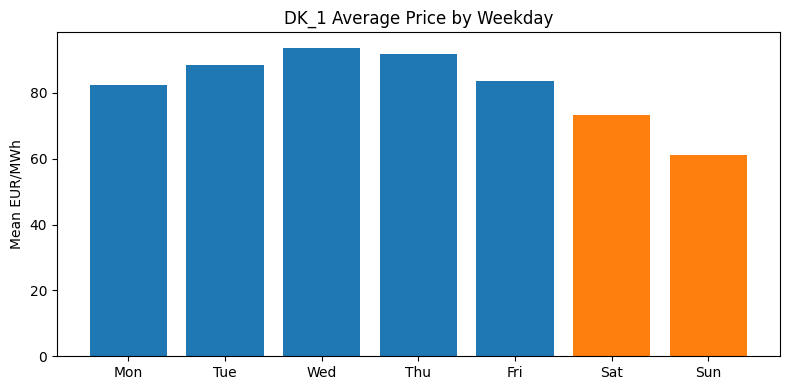

In [3]:
weekday_names = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
weekly = dk1.groupby("weekday")["price_eur_mwh"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#1f77b4"] * 5 + ["#ff7f0e"] * 2
ax.bar(range(7), weekly.values, color=colors)
ax.set_xticks(range(7))
ax.set_xticklabels(weekday_names)
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("DK_1 Average Price by Weekday")
fig.tight_layout()
plt.show()

### Monthly Pattern
Seasonal shape driven by heating demand (winter), cooling (summer in DE_LU coupling), and renewable generation profiles.

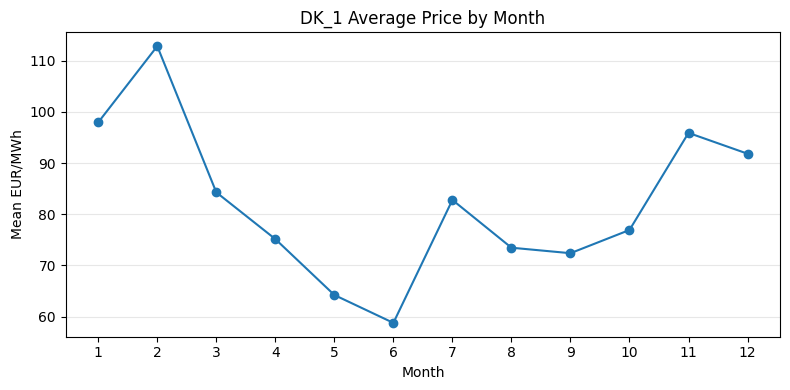

In [4]:
monthly = dk1.groupby("month")["price_eur_mwh"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly.index, monthly.values, marker="o", color="#1f77b4")
ax.set_xticks(monthly.index)
ax.set_xlabel("Month")
ax.set_ylabel("Mean EUR/MWh")
ax.set_title("DK_1 Average Price by Month")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

### Price Distribution
Heavy-tailed distribution. Negative prices indicate surplus renewable generation exceeding export capacity + demand. These hours are the primary forecasting challenge.

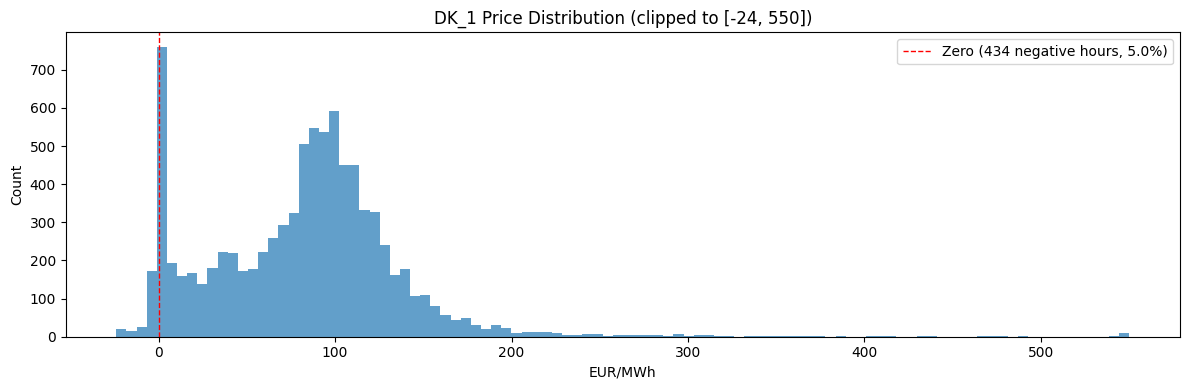

In [5]:
fig, ax = plt.subplots(figsize=(12, 4))

prices = dk1["price_eur_mwh"]
neg_mask = prices < 0

# Clip for visualization, note clipping range in title
clip_lo, clip_hi = prices.quantile(0.001), prices.quantile(0.999)
ax.hist(prices.clip(clip_lo, clip_hi), bins=100, color="#1f77b4", alpha=0.7, edgecolor="none")
ax.axvline(0, color="red", linewidth=1, linestyle="--", label=f"Zero ({neg_mask.sum()} negative hours, {neg_mask.mean():.1%})")
ax.set_xlabel("EUR/MWh")
ax.set_ylabel("Count")
ax.set_title(f"DK_1 Price Distribution (clipped to [{clip_lo:.0f}, {clip_hi:.0f}])")
ax.legend()
fig.tight_layout()
plt.show()

### DK1-DK2 Spread
The spread reflects Great Belt congestion. When the 600 MW link saturates, prices decouple. DK1 more exposed to DE_LU, DK2 to SE4.

Spread stats (DK1 - DK2):
count    8758.00
mean       -1.01
std        14.72
min      -266.63
25%        -0.61
50%         0.00
75%         0.01
max       106.89
Name: spread, dtype: float64

Hours with identical price: 3279 / 8758 (37.4%)


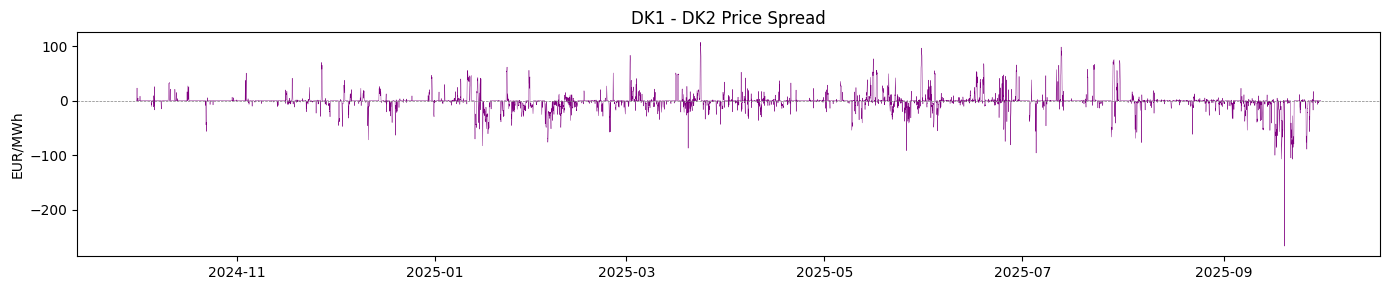

In [6]:
spread = dk1[["price_eur_mwh"]].join(dk2[["price_eur_mwh"]], lsuffix="_dk1", rsuffix="_dk2", how="inner")
spread["spread"] = spread["price_eur_mwh_dk1"] - spread["price_eur_mwh_dk2"]

print(f"Spread stats (DK1 - DK2):")
print(spread["spread"].describe().round(2))
print(f"\nHours with identical price: {(spread['spread'].abs() < 0.01).sum()} / {len(spread)} ({(spread['spread'].abs() < 0.01).mean():.1%})")

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(spread.index, spread["spread"], linewidth=0.3, color="purple")
ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
ax.set_ylabel("EUR/MWh")
ax.set_title("DK1 - DK2 Price Spread")
fig.tight_layout()
plt.show()

### Rolling Volatility
7-day rolling std captures regime changes -- storm fronts, cold snaps, interconnector outages all show up here.

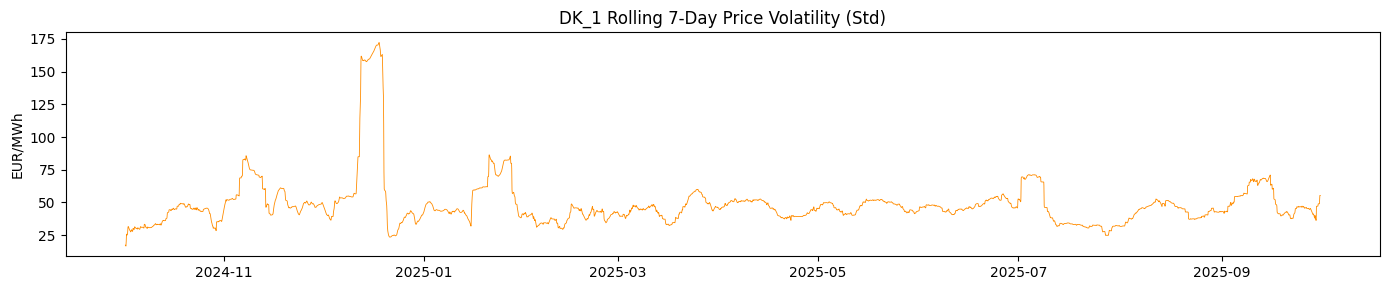

In [7]:
dk1["rolling_7d_std"] = dk1["price_eur_mwh"].rolling(7 * 24, min_periods=24).std()

fig, ax = plt.subplots(figsize=(14, 3))
ax.plot(dk1.index, dk1["rolling_7d_std"], linewidth=0.6, color="darkorange")
ax.set_ylabel("EUR/MWh")
ax.set_title("DK_1 Rolling 7-Day Price Volatility (Std)")
fig.tight_layout()
plt.show()

### Top 10 Extreme Price Hours
Extreme prices cluster around specific events. Context (wind drop, cold snap, interconnector trip) matters more than the absolute level.

In [8]:
print("Top 10 highest prices:")
top_high = dk1.nlargest(10, "price_eur_mwh")[["price_eur_mwh", "hour", "weekday"]].copy()
top_high["weekday"] = top_high["weekday"].map(dict(enumerate(weekday_names)))
display(top_high)

print("\nTop 10 lowest (most negative) prices:")
top_low = dk1.nsmallest(10, "price_eur_mwh")[["price_eur_mwh", "hour", "weekday"]].copy()
top_low["weekday"] = top_low["weekday"].map(dict(enumerate(weekday_names)))
display(top_low)

Top 10 highest prices:


,price_eur_mwh,hour,weekday
HourUTC,,,
2024-12-12 17:00:00+01:00,936.280029,17,Thu
2024-12-12 16:00:00+01:00,818.979980,16,Thu
2024-12-12 18:00:00+01:00,674.179993,18,Thu
2024-12-12 15:00:00+01:00,668.489990,15,Thu
2024-12-12 08:00:00+01:00,655.599976,8,Thu
2024-12-12 09:00:00+01:00,646.760010,9,Thu
2024-12-12 07:00:00+01:00,599.989990,7,Thu
2025-01-20 17:00:00+01:00,583.400024,17,Mon
2024-12-12 19:00:00+01:00,551.010010,19,Thu



Top 10 lowest (most negative) prices:


,price_eur_mwh,hour,weekday
HourUTC,,,
2025-08-10 14:00:00+02:00,-38.139999,14,Sun
2025-09-07 13:00:00+02:00,-34.040001,13,Sun
2025-09-07 14:00:00+02:00,-31.790001,14,Sun
2025-04-06 15:00:00+02:00,-30.100000,15,Sun
2025-08-10 13:00:00+02:00,-26.860001,13,Sun
2025-06-21 14:00:00+02:00,-26.309999,14,Sat
2025-06-21 13:00:00+02:00,-26.059999,13,Sat
2025-09-07 12:00:00+02:00,-25.320000,12,Sun
2025-04-05 12:00:00+02:00,-24.090000,12,Sat
